In [0]:
file_path = "/Volumes/azure_demo/default/workforce_data"
df = spark.read.option("header", "true").csv(file_path)

# Show schema and first few rows
df.printSchema()
display(df.limit(5))

root
 |-- company: string (nullable = true)
 |-- layoff_date: string (nullable = true)
 |-- jobs_cut: string (nullable = true)
 |-- pct_workforce_cut: string (nullable = true)
 |-- sector: string (nullable = true)
 |-- country: string (nullable = true)
 |-- hq_city: string (nullable = true)
 |-- ai_cited: string (nullable = true)
 |-- reason_stated: string (nullable = true)
 |-- company_revenue_2025_bn: string (nullable = true)
 |-- pre_layoff_headcount: string (nullable = true)
 |-- stock_change_day_pct: string (nullable = true)
 |-- simultaneous_ai_investment_bn: string (nullable = true)
 |-- roles_most_affected: string (nullable = true)
 |-- replacement_roles: string (nullable = true)
 |-- ceo_quote: string (nullable = true)
 |-- layoffs_2024: string (nullable = true)
 |-- layoffs_2025: string (nullable = true)
 |-- verified_source: string (nullable = true)
 |-- month: string (nullable = true)
 |-- quarter: string (nullable = true)
 |-- region: string (nullable = true)
 |-- layoff_s

company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,pre_layoff_headcount,stock_change_day_pct,simultaneous_ai_investment_bn,roles_most_affected,replacement_roles,ceo_quote,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,1550000,1.2,100.0,"Middle management, program managers","AI engineers, data architects",Moving faster with fewer layers,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,10000,5.8,2.0,"QA testers, customer support, content","AI prompt engineers, ML engineers",Smaller team using AI can do more,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.0,"March 18, 2026"
Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,79000,2.1,115.0,"VR/AR engineers, metaverse designers","AI researchers, LLM engineers",Redirecting investment toward AI R&D,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.9,"March 18, 2026"
Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,16000,2.0,0.5,"R&D engineers, QA, IT ops","AI product managers, enterprise sales",Bar for great software companies has gone up,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.0,"March 18, 2026"
Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,200000,3.5,40.0,"IT operations, database admins, support","AI infrastructure engineers, GPU specialists",Swapping workers for AI chips,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.0,"March 18, 2026"


In [0]:
from pyspark.sql.functions import col, to_date, when, regexp_replace, round
from pyspark.sql.types import IntegerType, FloatType

# Convert jobs_cut to integer (remove commas)
df = df.withColumn("jobs_cut", regexp_replace(col("jobs_cut"), ",", "").cast(IntegerType()))

# Convert pct_workforce_cut to float (remove %)
df = df.withColumn("pct_workforce_cut", 
                   regexp_replace(col("pct_workforce_cut"), "%", "").cast(FloatType()))

# Convert company_revenue_2025_bn to float
df = df.withColumn("company_revenue_2025_bn", col("company_revenue_2025_bn").cast(FloatType()))

# Convert layoff_date to date
df = df.withColumn("layoff_date", to_date(col("layoff_date"), "yyyy-MM-dd"))

# Fill missing AI_cited with 'False'
df = df.fillna({"ai_cited": "False"})

# Drop rows where jobs_cut is null (if any)
df = df.filter(col("jobs_cut").isNotNull())

# Optional: show cleaned data
display(df.limit(5))

company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,pre_layoff_headcount,stock_change_day_pct,simultaneous_ai_investment_bn,roles_most_affected,replacement_roles,ceo_quote,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,1550000,1.2,100.0,"Middle management, program managers","AI engineers, data architects",Moving faster with fewer layers,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,10000,5.8,2.0,"QA testers, customer support, content","AI prompt engineers, ML engineers",Smaller team using AI can do more,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.0,"March 18, 2026"
Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,79000,2.1,115.0,"VR/AR engineers, metaverse designers","AI researchers, LLM engineers",Redirecting investment toward AI R&D,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.9,"March 18, 2026"
Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,16000,2.0,0.5,"R&D engineers, QA, IT ops","AI product managers, enterprise sales",Bar for great software companies has gone up,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.0,"March 18, 2026"
Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,200000,3.5,40.0,"IT operations, database admins, support","AI infrastructure engineers, GPU specialists",Swapping workers for AI chips,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.0,"March 18, 2026"


In [0]:
# Flag for AI-related layoffs
df = df.withColumn("ai_related", when(col("ai_cited") == "True", 1).otherwise(0))

# Extract month (YYYY-MM) for time trends
from pyspark.sql.functions import date_format
df = df.withColumn("month", date_format(col("layoff_date"), "yyyy-MM"))

In [0]:
from pyspark.sql.functions import sum, count, avg

sector_summary = df.groupBy("sector") \
    .agg(sum("jobs_cut").alias("total_jobs_cut"),
         count("*").alias("event_count")) \
    .orderBy(col("total_jobs_cut").desc())

display(sector_summary)

sector,total_jobs_cut,event_count
Enterprise Software,31600,2
Social Media/AI,16000,1
E-Commerce/Cloud,16000,1
Telecommunications,6963,3
Networking/Cybersecurity,6000,1
Fintech,4000,1
Semiconductors,3700,2
Enterprise SaaS,2200,1
Manufacturing,2000,2
Logistics Software,2000,1


In [0]:
region_summary = df.groupBy("region") \
    .agg(sum("jobs_cut").alias("total_jobs_cut")) \
    .orderBy(col("total_jobs_cut").desc())

display(region_summary)

region,total_jobs_cut
North America,85046
Europe,11500
Asia-Pacific,4600


In [0]:
ai_summary = df.groupBy("ai_cited") \
    .agg(sum("jobs_cut").alias("total_jobs_cut"),
         count("*").alias("events")) \
    .withColumn("percentage", round(100 * col("total_jobs_cut") / 
                                    df.agg(sum("jobs_cut")).collect()[0][0], 1))


In [0]:
monthly_trend = df.groupBy("month") \
    .agg(sum("jobs_cut").alias("monthly_jobs_cut")) \
    .orderBy("month")

display(monthly_trend)

month,monthly_jobs_cut
2026-01,32800
2026-02,46588
2026-03,21758


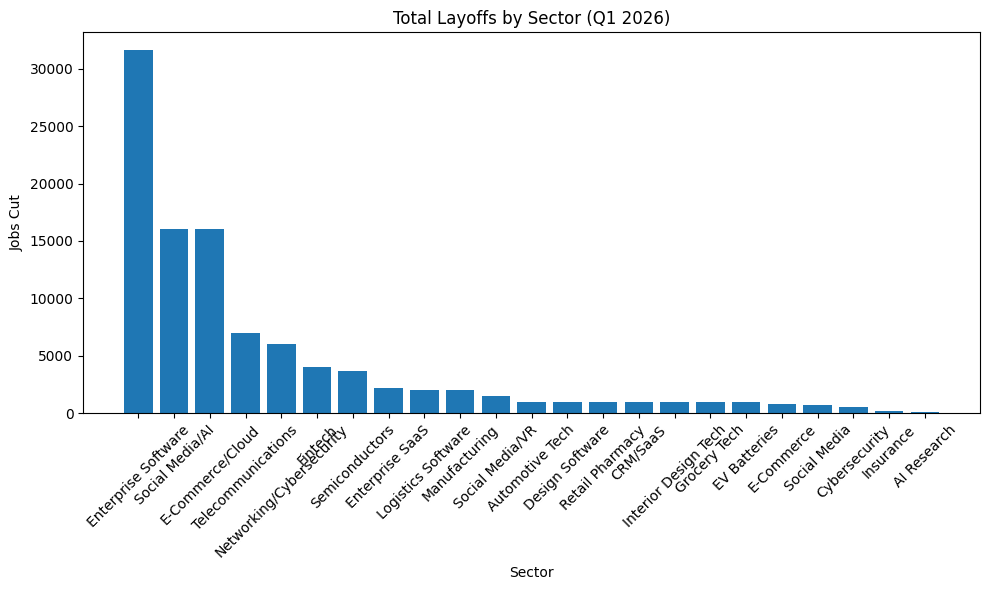

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

sector_pd = sector_summary.toPandas()
plt.figure(figsize=(10,6))
plt.bar(sector_pd['sector'], sector_pd['total_jobs_cut'])
plt.xticks(rotation=45)
plt.title('Total Layoffs by Sector (Q1 2026)')
plt.xlabel('Sector')
plt.ylabel('Jobs Cut')
plt.tight_layout()
plt.savefig('/tmp/sector_layoffs.png')  # will save to DBFS
plt.show()

In [0]:
# Save as a managed Delta table (no need to specify a path)
df.write.format("delta").mode("overwrite").saveAsTable("default.tech_layoffs")

# Verify
display(spark.sql("SELECT * FROM default.tech_layoffs LIMIT 5"))

company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,pre_layoff_headcount,stock_change_day_pct,simultaneous_ai_investment_bn,roles_most_affected,replacement_roles,ceo_quote,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of,ai_related
Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,1550000,1.2,100.0,"Middle management, program managers","AI engineers, data architects",Moving faster with fewer layers,4000,14000,CNBC / NetworkWorld,2026-01,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026",0
Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,10000,5.8,2.0,"QA testers, customer support, content","AI prompt engineers, ML engineers",Smaller team using AI can do more,0,1000,CNBC / Crunchbase,2026-02,Q1 2026,North America,Large (2K-5K),Positive,40.0,"March 18, 2026",1
Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,79000,2.1,115.0,"VR/AR engineers, metaverse designers","AI researchers, LLM engineers",Redirecting investment toward AI R&D,0,500,InformationWeek / NYT,2026-01,Q1 2026,North America,Medium (500-2K),Positive,1.9,"March 18, 2026",1
Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,16000,2.0,0.5,"R&D engineers, QA, IT ops","AI product managers, enterprise sales",Bar for great software companies has gone up,0,500,TechRepublic / Metaintro,2026-03,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.0,"March 18, 2026",1
Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,200000,3.5,40.0,"IT operations, database admins, support","AI infrastructure engineers, GPU specialists",Swapping workers for AI chips,6000,10000,IBTimes,2026-02,Q1 2026,North America,Mega (5K+),Positive,15.0,"March 18, 2026",1
